In [1]:
import pandas as pd
import matplotlib.pyplot as plt

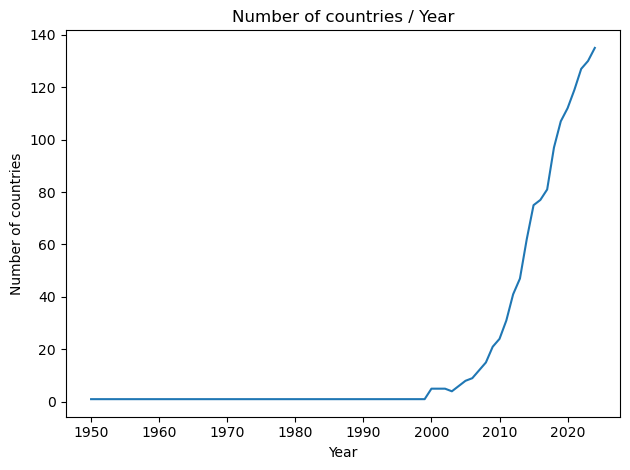

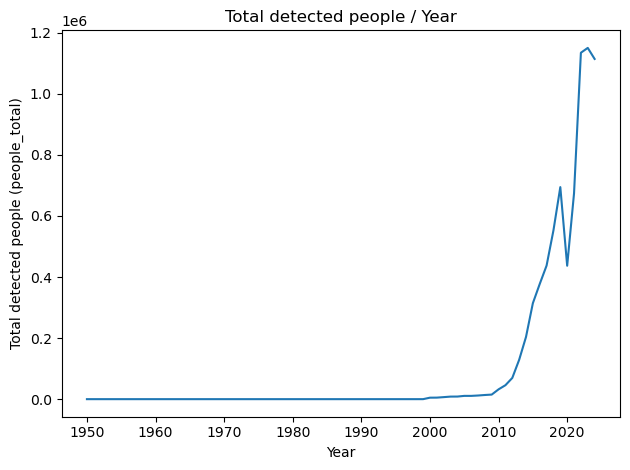

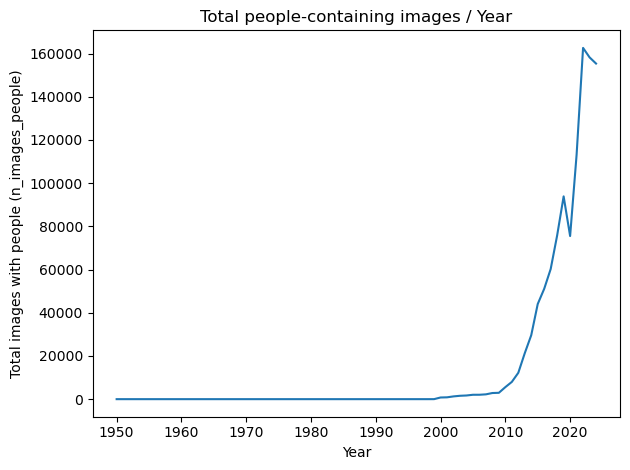

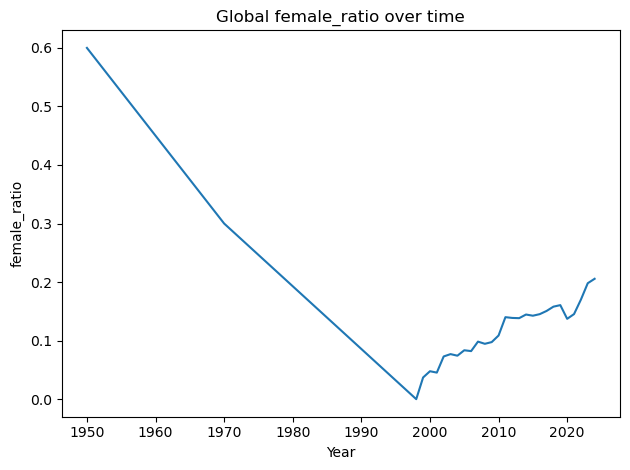

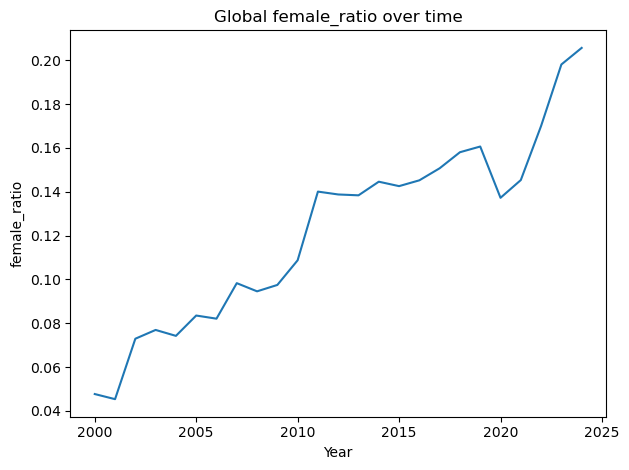

In [2]:
CY_PATH = "country_year_women_ratio.csv"
OUT_PREFIX = "fig"
CUTOFF_YEAR = 2000

cy = pd.read_csv(CY_PATH)

def savefig_both(name):
    plt.tight_layout()
    plt.savefig(f"{OUT_PREFIX}_{name}.pdf", bbox_inches="tight")
    plt.savefig(f"{OUT_PREFIX}_{name}.png", dpi=300, bbox_inches="tight")

# coverage by all years 
year_cov = (
    cy.groupby("year", as_index=False)
      .agg(
          n_countries=("country", "nunique"),
          rows=("country", "size"),
          people_total=("people_total", "sum"),
          n_images_people=("n_images_people", "sum"),
      )
      .sort_values("year")
)

# Fig 1: number of countries
plt.figure()
plt.plot(year_cov["year"], year_cov["n_countries"])
plt.title("Number of countries / Year")
plt.xlabel("Year")
plt.ylabel("Number of countries")
savefig_both("coverage_countries_by_year")
plt.show()

# Fig 2: total detected people
plt.figure()
plt.plot(year_cov["year"], year_cov["people_total"])
plt.title("Total detected people / Year")
plt.xlabel("Year")
plt.ylabel("Total detected people (people_total)")
savefig_both("coverage_people_total_by_year")
plt.show()

# Fig 3: people containing images
plt.figure()
plt.plot(year_cov["year"], year_cov["n_images_people"])
plt.title("Total people-containing images / Year")
plt.xlabel("Year")
plt.ylabel("Total images with people (n_images_people)")
savefig_both("coverage_images_by_year")
plt.show()

# global female_ratio trend 
def plot_global_trend(df, suffix):
    global_year = (
        df.groupby("year", as_index=False)
          .agg(female_total=("female_total", "sum"),
               people_total=("people_total", "sum"))
    )
    global_year = global_year[global_year["people_total"] > 0].copy()
    global_year["female_ratio"] = global_year["female_total"] / global_year["people_total"]

    plt.figure()
    plt.plot(global_year["year"], global_year["female_ratio"])
    plt.title("Global female_ratio over time")
    plt.xlabel("Year")
    plt.ylabel("female_ratio")
    savefig_both(f"global_female_ratio_{suffix}")
    plt.show()

plot_global_trend(cy, "all_years")
plot_global_trend(cy[cy["year"] >= CUTOFF_YEAR].copy(), "post2000")



In [3]:
CY_PATH = "country_year_women_ratio.csv"
CUTOFF_YEAR = 2000

cy = pd.read_csv(CY_PATH)

year_cov = (
    cy.groupby("year", as_index=False)
      .agg(
          n_countries=("country", "nunique"),
          rows=("country", "size"),
          people_total=("people_total", "sum"),
          n_images_people=("n_images_people", "sum"),
      )
      .sort_values("year")
)

pre_table = year_cov[year_cov["year"] < CUTOFF_YEAR].copy()

print("Pre-2000 coverage table:")
print(pre_table)


Pre-2000 coverage table:
   year  n_countries  rows  people_total  n_images_people
0  1950            1     1            10                1
1  1970            1     1            10                2
2  1998            1     1             1                1
3  1999            1     1            27                9


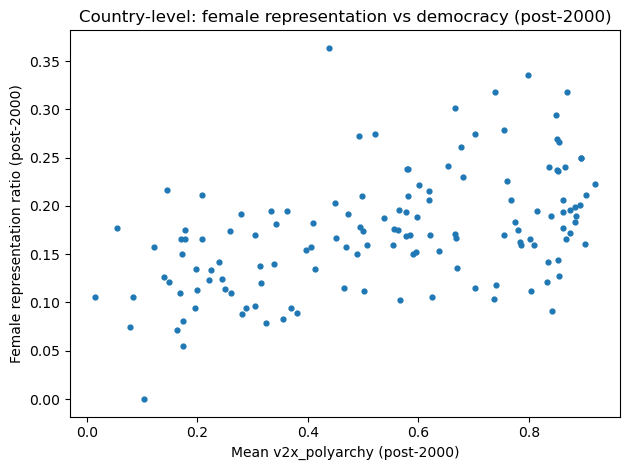

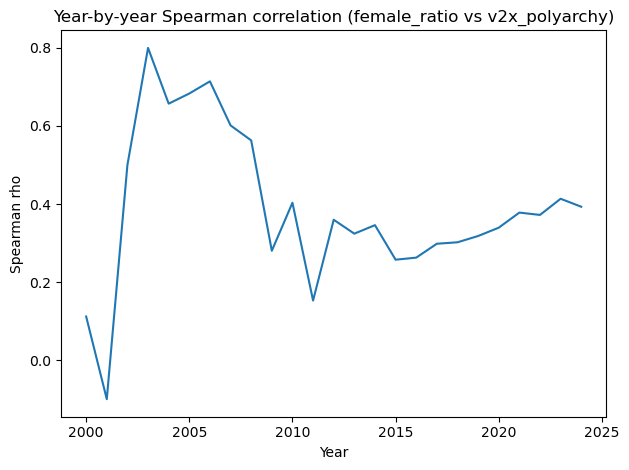

In [4]:
CYVDEM_PATH = "country_year_women_ratio_vdem.csv" 
OUT_PREFIX = "fig"

df = pd.read_csv(CYVDEM_PATH)
df = df[df["year"] >= 2000].copy()

# keeping only rows usable for exploratory plots
df = df.dropna(subset=["female_ratio", "v2x_polyarchy", "people_total", "female_total"]).copy()
df = df[df["people_total"] > 0].copy()


def savefig_both(name):
    plt.tight_layout()
    plt.savefig(f"{OUT_PREFIX}_{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{OUT_PREFIX}_{name}.pdf", bbox_inches="tight")


# Country-level scatter 
country = (df.groupby("country", as_index=False)
             .agg(
                 female_total=("female_total", "sum"),
                 people_total=("people_total", "sum"),
                 polyarchy_mean=("v2x_polyarchy", "mean"),
             ))
country["female_ratio_country"] = country["female_total"] / country["people_total"]

plt.figure()
plt.scatter(country["polyarchy_mean"], country["female_ratio_country"], s=12)
plt.title("Country-level: female representation vs democracy (post-2000)")
plt.xlabel("Mean v2x_polyarchy (post-2000)")
plt.ylabel("Female representation ratio (post-2000)")
savefig_both("scatter_country_female_vs_polyarchy_post2000")
plt.show()

# Year-by-year Spearman rho 
def spearman_rho_xy(g):
    return g["female_ratio"].corr(g["v2x_polyarchy"], method="spearman")

by_year = (df.groupby("year", group_keys=False)[["female_ratio", "v2x_polyarchy"]]
             .apply(spearman_rho_xy)
             .reset_index(name="spearman_rho"))


plt.figure()
plt.plot(by_year["year"], by_year["spearman_rho"])
plt.title("Year-by-year Spearman correlation (female_ratio vs v2x_polyarchy)")
plt.xlabel("Year")
plt.ylabel("Spearman rho")
savefig_both("spearman_by_year_post2000")
plt.show()
